# Module 3 Homework - Seaborn
Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://cdn.arstechnica.net/wp-content/uploads/2020/07/pokemon-go-masks-800x450.jpg">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"
poke_data=pd.read_csv(fp)

## Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Use `hue` to display the `HP` (hit point) for each datapoint. You can choose your favorite palette. Include a meaninful title in the plot. After creating the plot, insert a markdown cell :immediately following the plot to describe the relationship between Attack and Defense in this dataset.

### From the plot, I observed....
Results: There is a positive correlation between `Attack` and `Defense`. The hit-points (`HP`) is higher for Pokemons with higher `Attack` and `Defense` values.

Text(0.5, 1.0, 'Pokemon attack and its respective base defense')

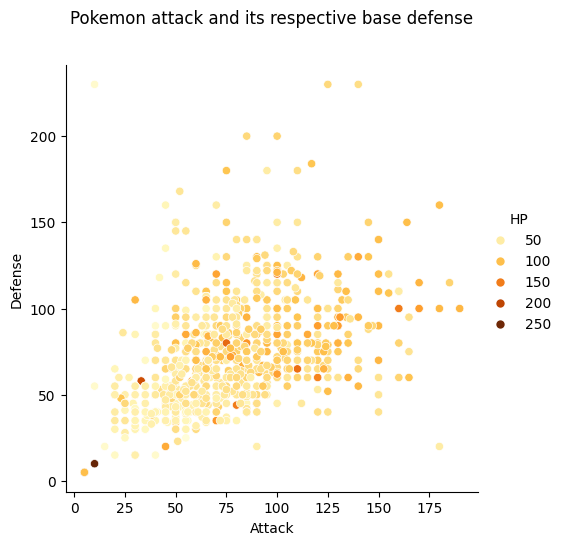

In [9]:
# Your code here . . .
sns.relplot(data=poke_data, x="Attack", y="Defense", hue="HP", palette='YlOrBr')
plt.title("Pokemon attack and its respective base defense", pad=30)

According to the plot, there seems to be a relatively linear relationship between basic attack and basic defense. This means that higher attack values are usually associated with higher defense, although, it's good to keep in mind that there are a couple outliers and that the distribution gets sparser as both the basic attack and defense gets larger. With regards to HP, the majority of the points have either 50 or 100 with a few outliers as well.

## Q2: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `joinplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot "Attack vs total for all Pokemon". After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Attack` and `Total`, what else does this plot show?

Text(0.5, 1.05, 'Attack vs total for all Pokemon')

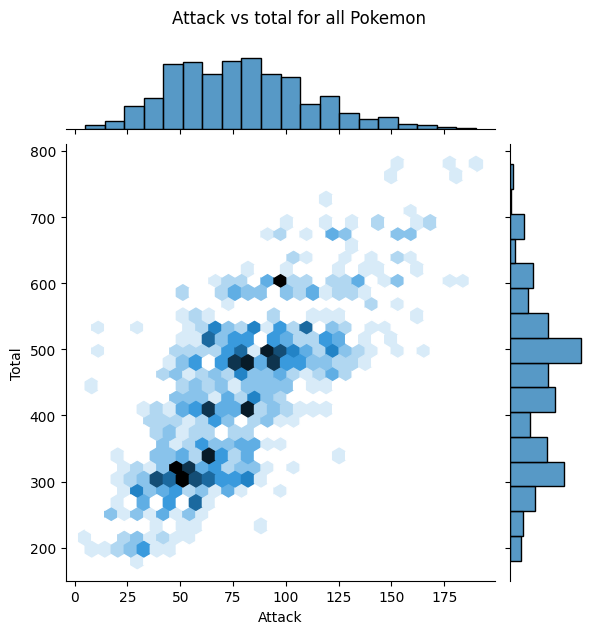

In [15]:
# Your code here . . .
g=sns.jointplot(data=poke_data, x="Attack", y="Total", kind="hex", gridsize=30)
g.fig.suptitle("Attack vs total for all Pokemon", y=1.05)

There seems to be a linear relationshsiip between the attack and the total strength of each pokemon. It's mostly concentrated around total strength ranging from 300 to 600. A distinct groups of attack cluster around 50 and 75 with less saturated groupings in the vicinity of those values.

## Q3: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

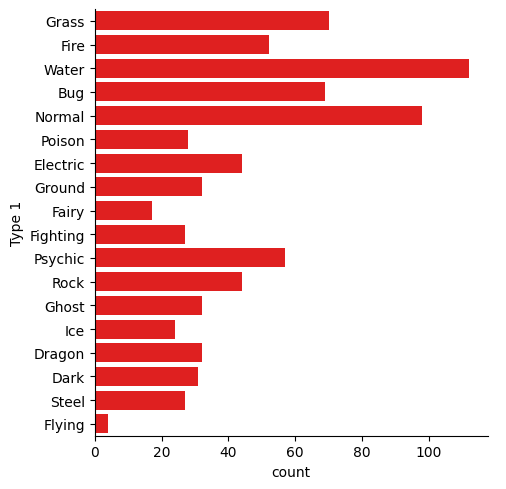

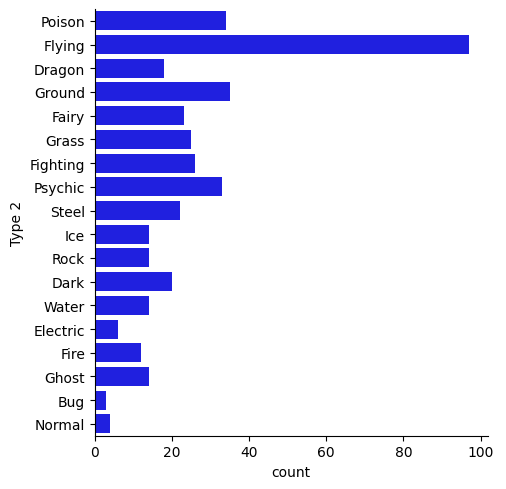

In [17]:
# Your code here . . .
sns.catplot(data=poke_data, y="Type 1", kind="count", color="red")
sns.catplot(data=poke_data, y="Type 2", kind="count", color="blue")
plt.show()

## Q4-6: Your own question
Come up with three more questions to further explore the pokemon dataset.

Your question(s) . . .

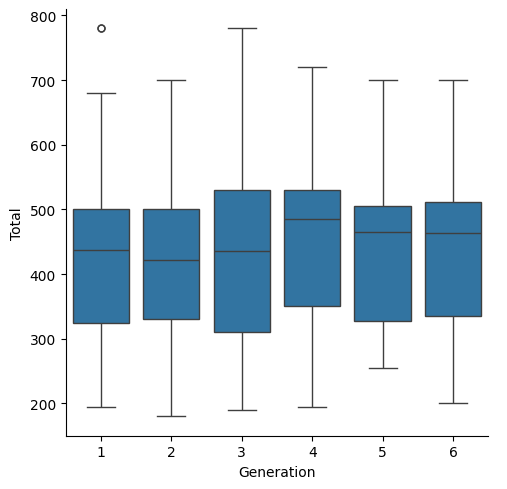

In [18]:
# Your code here . . .
#Q4 Which generation released stronger pokemons?
sns.catplot(data=poke_data, x="Generation", y="Total", kind="box")

The overall spread looks relatively similar. However in terms of average strength, generation 4 is slighter higher than the rest. On the other hand, generation 1 and 3 released the two strongest pokemons.

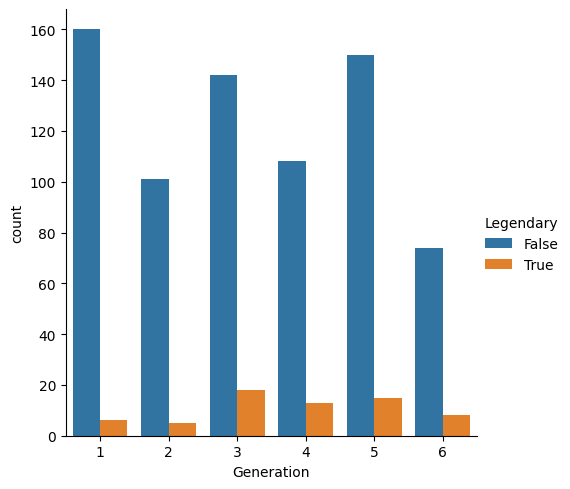

In [20]:
#Q5. Which generation released more legendary pokemons?
sns.catplot(data=poke_data, x="Generation", kind="count", hue="Legendary")

Generation 3 released the most legendary pokemons and 2 with the least.

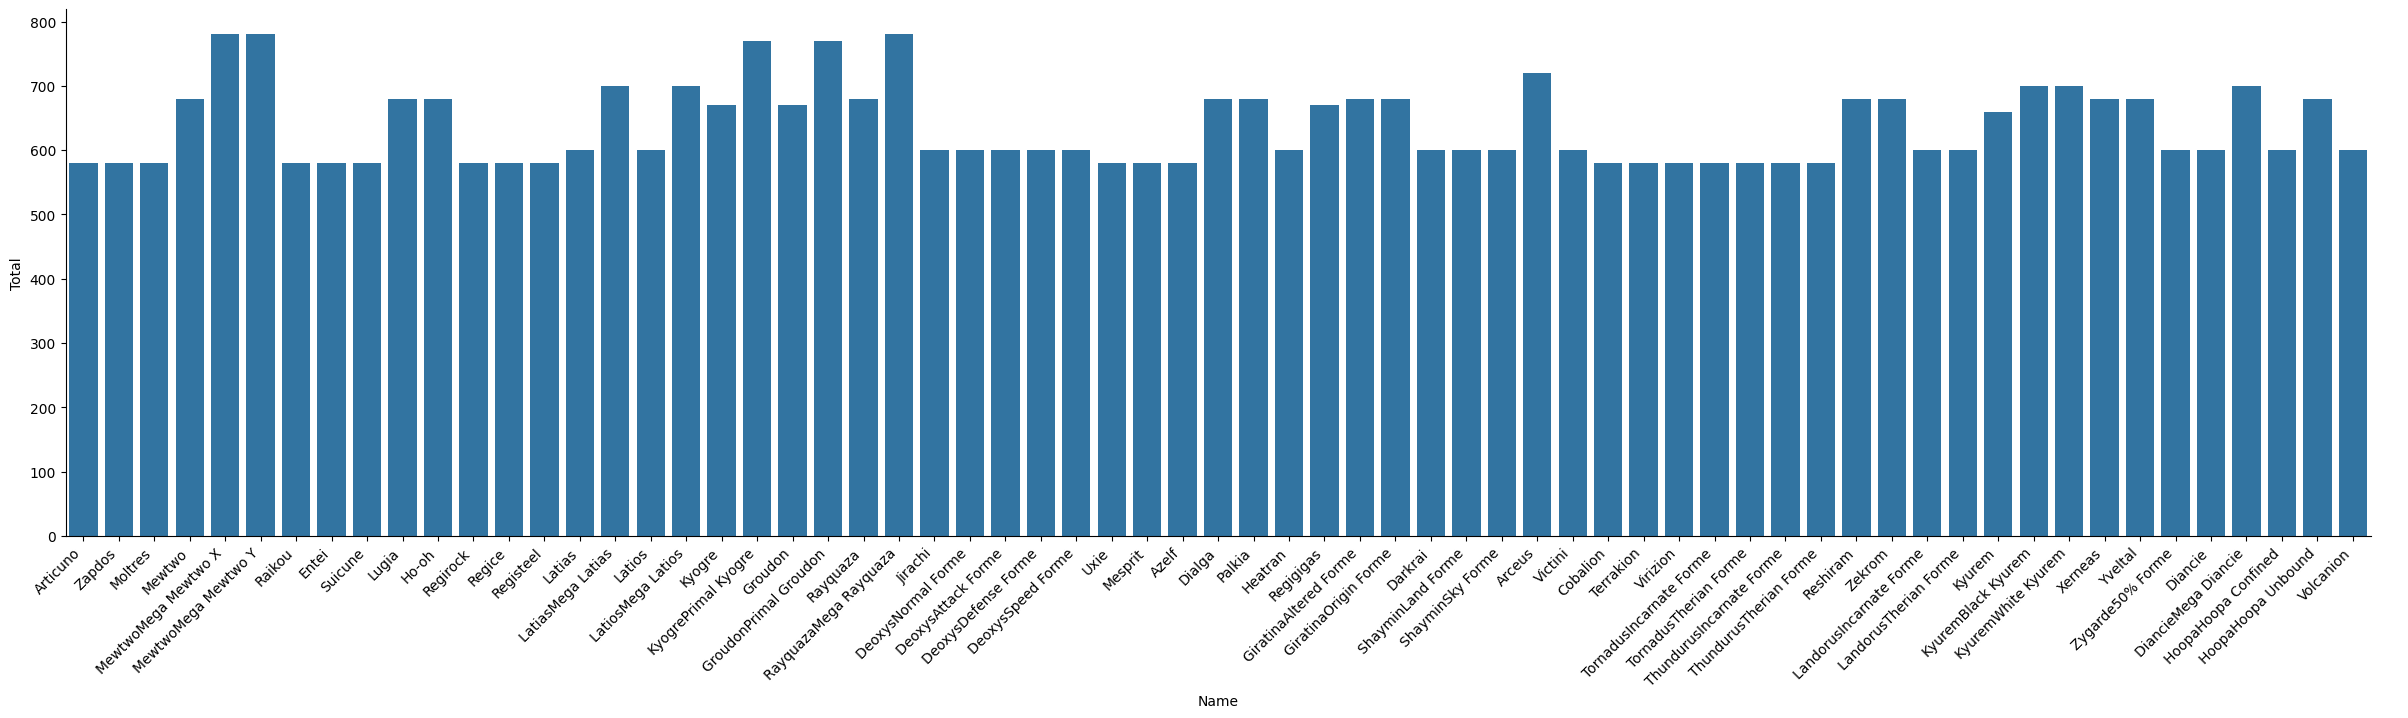

In [23]:
#Q6. Which legendary pokemon has the greates strength overall?
legendary_poke = poke_data[poke_data["Legendary"] == True]
g=sns.catplot(data=legendary_poke, x="Name", y="Total", kind="bar", height=6, aspect=4)
g.set_xticklabels(rotation=45, ha="right")